<h3 align="center"><b>Unnas Hussain</b></h3>

# Q1: Outlier Detection with Mahalanobis Distance

Developing multi-variate methods for outlier detection (40 points total)

---

## Conceptual Understanding (10 points)
The Mahalanobis distance-based ellipses is just one possible method for detecting outliers, but has specific advantages and disadvantages. Firstly, it is a multivariate outlier technique, so it is creating bounds for outliers in two dimensions (as opposed to standard deviation-based methods). The actual Mahalanobis Distance equation can in fact be n-dimensional, as long as you have the covariance matrix defined.

## Implementation (10 points)

In [105]:
import warnings
warnings.filterwarnings("ignore")

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh
import math
from scipy.stats.distributions import chi2
from scipy.stats import norm
from scipy import stats
import seaborn as sns
from sklearn import datasets
#%matplotlib inline

class sigma_ellipse_plot:

    # task 2b: this class supports custom standard deviation thresholds with the std_devs parameters
    def __init__(self, df=None, target='setosa', target_header='species', feature1='sepal_length', feature2='petal_width', std_devs=[1, 2, 3]):

        self.data = df
        self.target = target
        self.feature1 = feature1
        self.feature2 = feature2
        self.target_header = target_header
        self.std_devs=std_devs
        self.largest_eigenvalue = None
        self.largest_eigenvector = None
        self.smallest_eigenvalue = None
        self.smallest_eigenvector = None
        self.angle = None
        self.mean = None
        self.r_ellipses = None
        self.mu_X = None
        self.mu_Y = None
        self.chisquare_val = None

    def get_data(self):

        self.data = self.data[self.data[self.target_header] == self.target].drop(self.target_header, axis =1)[[self.feature1, self.feature2]]

        return

    def get_eigens(self):

        covariance_matrix = self.data.cov()
        eigenvalues, eigenvectors = eigh(covariance_matrix)

        self.largest_eigenvector = eigenvectors[np.argmax(eigenvalues)]
        self.largest_eigenvalue = np.max(eigenvalues)
        self.smallest_eigenvector = eigenvectors[np.argmin(eigenvalues)]
        self.smallest_eigenvalue = np.min(eigenvalues)

        return

    def get_angle(self):

        self.angle = math.atan2(self.largest_eigenvector[1], self.largest_eigenvector[0])

        return

    def shift_angle(self):

        if self.angle < 0:
            self.angle = self.angle + 2*math.pi

        return

    def get_mean(self):

        self.mean = self.data.mean()

        return

    def get_chisquare_vals(self):

        self.chisquare_val = []
        for i in range(0, len(self.std_devs)):
            percent_covered = stats.norm.cdf(self.std_devs[i]) - stats.norm.cdf(self.std_devs[i] * -1)
            self.chisquare_val.append((chi2.ppf(percent_covered, df=2))**0.5)

        return self.chisquare_val

    def get_ellipses(self):

        chisquare_val = self.get_chisquare_vals()

        self.r_ellipses = []
        for i in range(0, len(self.std_devs)):
            theta_grid = np.linspace(0,2*math.pi, 100)
            phi = self.angle
            self.mu_X = self.mean[0]
            self.mu_Y = self.mean[1]
            a = chisquare_val[i] * math.sqrt(self.largest_eigenvalue)
            b = chisquare_val[i] * math.sqrt(self.smallest_eigenvalue)

            ellipse_x_r = a * np.cos(theta_grid)
            ellipse_y_r = b * np.sin(theta_grid)

            R = [[math.cos(phi), math.sin(phi)], [-math.sin(phi), math.cos(phi)]]

            ellipses = np.array([ellipse_x_r, ellipse_y_r])

            r_ellipse = ellipses.T.dot(R).T

            self.r_ellipses.append(r_ellipse)

        return
    
    def get_labels(self, special_phrase=None):

        labels = []
        for i in range(0, len(self.std_devs)):

            if special_phrase is None:
                label = str(self.std_devs[i]) + " std. dev. from mean"
                labels.append(label)
            else: 
                label = special_phrase + str(self.std_devs[i]) + " std. dev. from mean"
                labels.append(label)

        return labels
    
    def get_distances_from_mean_sorted(self):
        '''Get the sorted list of distances to bring outliers to the top. Assumes the pipeline has already been run'''
        cov_matrix = self.data.cov().values # E
        cov_inv = np.linalg.inv(cov_matrix) # E^-1

        # D_i = sqrt((x_i - mu) * E^-1 * (x_i - mu)^T)
        mu = self.mean.values
        distances = []
        for idx, row in self.data.iterrows():
            x_i = row.values
            diff = x_i - mu
            mahal_dist = np.sqrt(diff @ cov_inv @ diff)
            distances.append((idx, mahal_dist))

        # Sort distances
        self.mahal_distances = sorted(distances, key=lambda x: x[1], reverse=True)        

    def pipeline(self):

        self.get_data()
        self.get_eigens()
        self.get_angle()
        self.shift_angle()
        self.get_mean()
        self.get_ellipses()
        self.get_distances_from_mean_sorted()

        return self.data, self.r_ellipses, self.mu_X, self.mu_Y


In [107]:
## Import Dataset ##

iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.columns = (
    df.columns.str.replace(' ', '_') 
    .str.replace(r'\(cm\)', '', regex=True) 
    .str.lower()
    .str.rstrip('_')) 
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
print(df.head())

## Feature Definition ##

feature1 = 'sepal_length' # task 2a: sepal length set as first feature
feature2 = 'petal_width' # task 2a: fpetal width set as second feature

std_dev_threshs = [1, 2, 3] # task 2b: custom standard deviation thresholds

## Species Specific Ellipse Generation ##

setosa_ellipses_obj = sigma_ellipse_plot(df=df, target='setosa', feature1=feature1, feature2=feature2, std_devs=std_dev_threshs)
setosa_df, setosa_ellipses, setosa_mu_X, setosa_mu_Y = setosa_ellipses_obj.pipeline()
setosa_plot_labels = setosa_ellipses_obj.get_labels()


versicolor_ellipses_obj = sigma_ellipse_plot(df=df, target='versicolor', feature1=feature1, feature2=feature2, std_devs=std_dev_threshs)
versicolor_df, versicolor_ellipses, versicolor_mu_X, versicolor_mu_Y = versicolor_ellipses_obj.pipeline()
versicolor_plot_labels = versicolor_ellipses_obj.get_labels()

virginica_ellipses_obj = sigma_ellipse_plot(df=df, target='virginica', feature1=feature1, feature2=feature2, std_devs=std_dev_threshs)
virginica_df, virginica_ellipses, virginica_mu_X, virginica_mu_Y = virginica_ellipses_obj.pipeline()
virginica_plot_labels = virginica_ellipses_obj.get_labels()

print('Setosa farthest distance: ', setosa_ellipses_obj.mahal_distances[0])
print('Versicolor farthest distance: ', versicolor_ellipses_obj.mahal_distances[0])
print('Virginica farthest distance: ', virginica_ellipses_obj.mahal_distances[0])



   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Setosa farthest distance:  (43, np.float64(3.5020117478095787))
Versicolor farthest distance:  (70, np.float64(2.908407685006848))
Virginica farthest distance:  (106, np.float64(2.6940247497317076))


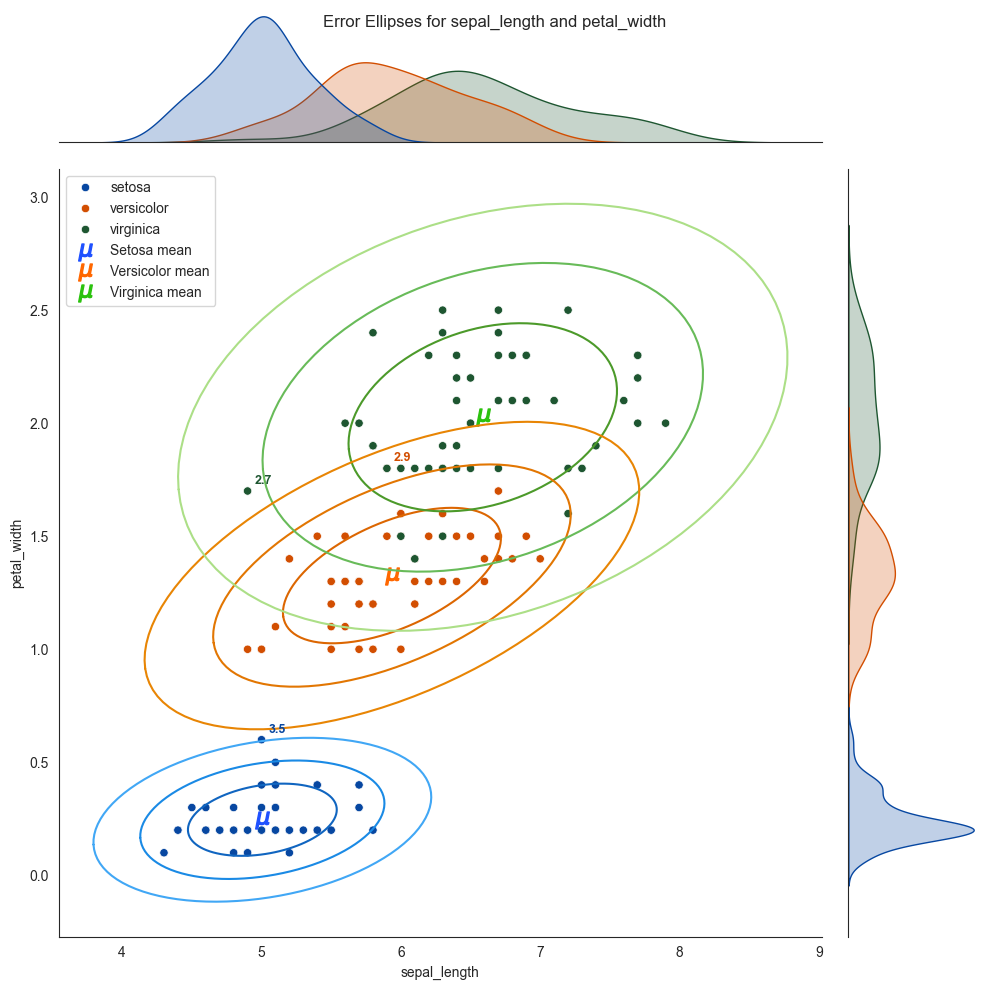

In [108]:
## Visualization of Ellipse Plots ##

sns.set_style("white")

df_subset = df[[feature1, feature2, 'species']]

# palette order - setosa, virginica, versicolor
petal_width_plot = sns.jointplot(data=df_subset, x=feature1, y=feature2, hue="species", palette = ["#0747a1", '#d24e01','#1e5631' ], height = 10)
colors_for_plot_setosa = ['#1065c0', '#1a8ae5', '#41a7f5']
colors_for_plot_virginica = ['#4c9a2a', '#68bb59', '#acdf87']
colors_for_plot_versicolor = ['#dc6601', '#e27602', '#e88504']

# Dynamic title for chart 
plt.suptitle(f"Error Ellipses for {feature1} and {feature2}" )

plt.scatter(setosa_mu_X, setosa_mu_Y, c='#1F51FF', s=150, label = 'Setosa mean', marker='$\mu$')
plt.scatter(versicolor_mu_X, versicolor_mu_Y, c='#FF6700', s=150, label = 'Versicolor mean', marker='$\mu$')
plt.scatter(virginica_mu_X, virginica_mu_Y, c='#2Bc20e', s=150, label = 'Virginica mean', marker='$\mu$')

plt.legend()

# Plots the ellipses for each species, with the appropriate colors 
for i in range(0, len(setosa_ellipses)):
    plt.plot(setosa_ellipses[i][0] + setosa_mu_X, setosa_ellipses[i][1] + setosa_mu_Y, colors_for_plot_setosa[i], label= setosa_plot_labels[i])
    plt.plot(versicolor_ellipses[i][0] + versicolor_mu_X, versicolor_ellipses[i][1] + versicolor_mu_Y, colors_for_plot_versicolor[i], label= versicolor_plot_labels[i])
    plt.plot(virginica_ellipses[i][0] + virginica_mu_X, virginica_ellipses[i][1] + virginica_mu_Y, colors_for_plot_virginica[i], label= virginica_plot_labels[i])

# Label the farthest outlier for each species
outliers = [
    (setosa_ellipses_obj, setosa_df, '#0747a1'),
    (versicolor_ellipses_obj, versicolor_df, '#d24e01'),
    (virginica_ellipses_obj, virginica_df, '#1e5631')
]

for obj, species_df, color in outliers:
    farthest_idx, farthest_dist = obj.mahal_distances[0]
    x = species_df.loc[farthest_idx, feature1]
    y = species_df.loc[farthest_idx, feature2]
    plt.annotate(f'{round(farthest_dist, 1)}', (x, y), textcoords='offset points', 
                 xytext=(5, 5), fontsize=9, color=color, fontweight='bold')

# Save the plot as an image
plt.savefig('MahalanobisOultlierExample.svg')

# Show the plot (optional)
plt.show()

## Analysis and Interpretation (10 points)
In the setosa data base, there is a data point that is outside the 3rd std dev ellipse. and a Mahalanobis Distance from the mean of 3.5. We can't simply use the ellipse boundaries or which data points are farthest to state an outlier, but when the Mahalanobis distance is > 3, we *can* label that point as an outlier.

The covariance matrix has a big influence on the ellipese. High covariance results in a larger difference between eigenvalues in the matrix, which results in a more elongated ellipse. If the eigenvectors also change, the tilt of the ellipse changes. A highly positive covariance will tilt the ellipse one way, and a highly negative covariance will tilt the ellipse the other way.

## Beyond Visual Identification (10 points)
The Mahalanobis Method does not just produce these ellipical plots, it also consists of a distance equation to find every data point's distance from their average (or their center on an n-dimensional plot). Sorting the data by that distance gives you which data points are closer/farther from being outliers, and a statistically standardized threshold of 3 for determining outliers.

# **Q2: Data Modeling**

Explore various approaches to formulating a problem statement and selecting the appropriate type of model for the task (30 points total)

---

##  **Understanding the Data (5 points)**

Below is python code parsing the data, performing quick statistical analysis, and printing/plotting the results

                imputed_pct  missing_pct data_type  unique_values  \
age                0.000000          0.0     int64            NaN   
capital_gain       0.000000          0.0     int64            NaN   
capital_loss       0.000000          0.0     int64            NaN   
education          0.000000          0.0    object           16.0   
education_num      0.000000          0.0     int64            NaN   
fnlwgt             0.000000          0.0     int64            NaN   
hours_per_week     0.000000          0.0     int64            NaN   
income             0.000000          0.0    object            2.0   
marital_status     0.000000          0.0    object            7.0   
native_country     1.790486          0.0    object           42.0   
occupation         5.660146          0.0    object           15.0   
race               0.000000          0.0    object            5.0   
relationship       0.000000          0.0    object            6.0   
sex                0.000000       

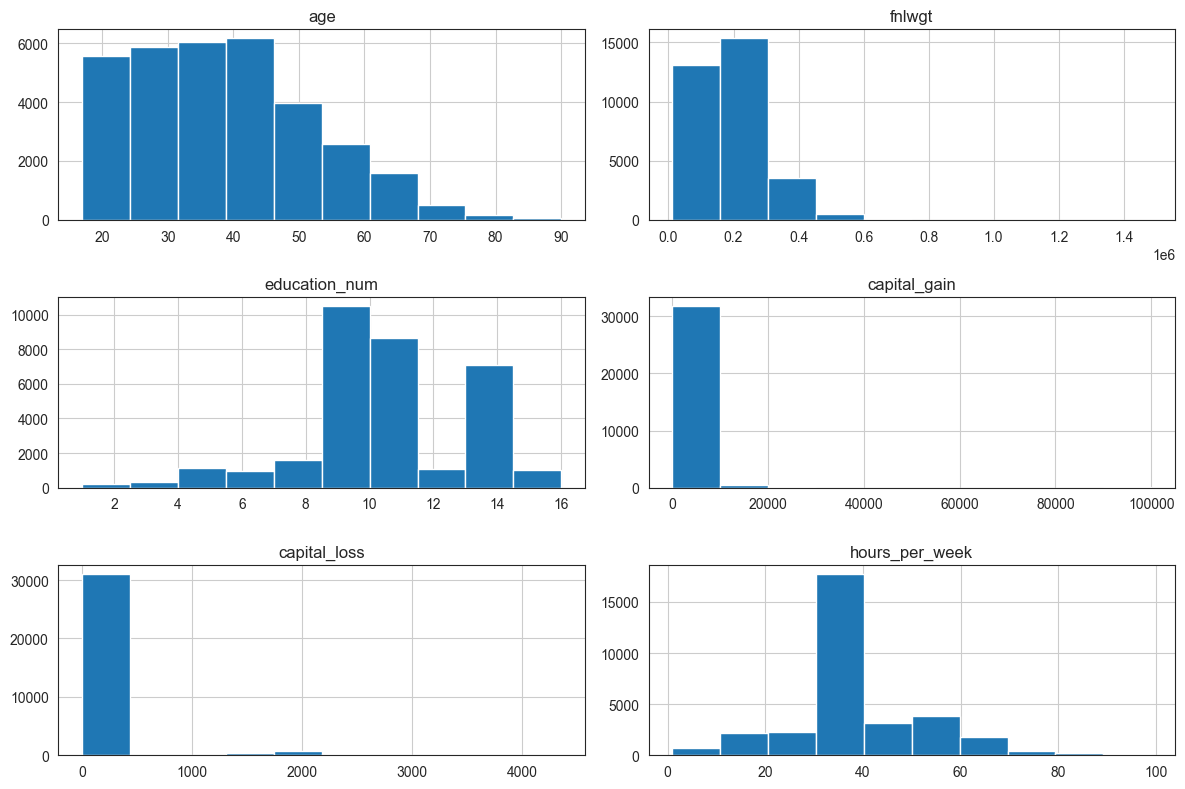

<Axes: xlabel='age', ylabel='Count'>

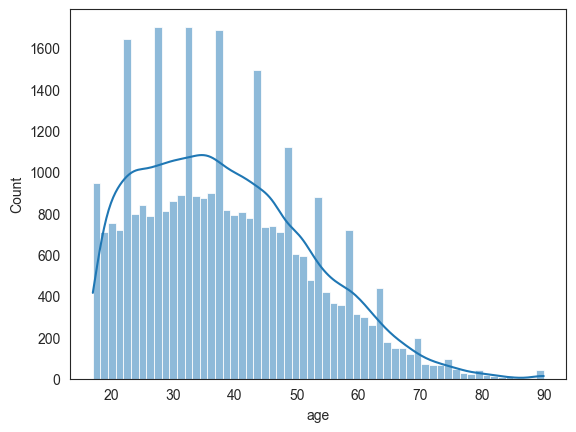

In [109]:
import pandas as pd
import numpy as np

column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status", 
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss", 
    "hours_per_week", "native_country", "income"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df = pd.read_csv(url, names=column_names, na_values=" ?", skipinitialspace=True)
df_raw = pd.read_csv(url, names=column_names, skipinitialspace=True) # Read raw without na_values conversion
df.to_csv('datasets/uci_adult_income.csv')

df.head()

# EDA
summary = pd.DataFrame({
    'imputed_pct': ((df_raw == '?').sum() / len(df_raw)) * 100,
    'missing_pct': (df.isnull().sum() / len(df)) * 100,
    'data_type': df.dtypes,
    'unique_values': df.nunique(dropna=True),
    'mean': df.mean(numeric_only=True),
    'median': df.median(numeric_only=True),
    'std_dev': df.std(numeric_only=True),
    'min': df.min(numeric_only=True),
    'max': df.max(numeric_only=True),
    'skewness': df.skew(numeric_only=True),
    'kurtosis': df.kurtosis(numeric_only=True)
})



# For categorical columns
summary['mode'] = df.mode().iloc[0]
summary['unique_values'] = df[df.select_dtypes(include=['object']).columns].nunique()
print(summary)

# Visualize numerical distributions
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()
sns.histplot(df['age'], kde=True)

## **Problem Formulation & Model Selection (10 points)**

1. Graph Algorithm - Network Analysis
    - **Problem Statement:** What is the relationship structure between occupations and education levels, and which career pathways are most associated with high income?
    - **Plan:**
        - Construct a bipartite network where education levels and occupations are nodes, with edges weighted by the number of people with that combination
        - Analyze network properties: Which education nodes have highest degree (connect to most occupations)? Which occupations are "hubs"?
        - Add income as edge attributes: What % of people on each edge earn >50K?
        - Identify the "shortest path to high income" - e.g., from "HS-grad" what occupation transitions lead to >50K earners?
        - Use community detection to find clusters of related education-occupation pairs

2. Unsupervised Learning - Clustering + Dimenstionality Reduction
    - **Problem Statement:** Are there natural demographic clusters within the population, and do these clusters correlate with income levels?
    - **Plan:**
        - Use PCA to reduce dimensionality and visualize high-dimensional data in 2D
        - Apply K-Means clustering to discover natural groupings of individuals
        - Analyze cluster composition: Do certain clusters have higher proportions of >50K earners?
        - Identify demographic profiles (e.g. "young professionals", "experienced specialists")

## **Implementation (10 points)**

Graph has 31 nodes and 217 edges
  education: 16 unique values
  occupation: 15 unique values

--- education by connectivity ---
  Bachelors: connects to 15 nodes
  HS-grad: connects to 15 nodes
  Masters: connects to 15 nodes
  Some-college: connects to 15 nodes
  12th: connects to 15 nodes

--- occupation by connectivity ---
  Prof-specialty: connects to 16 nodes
  Other-service: connects to 16 nodes
  Craft-repair: connects to 16 nodes
  Farming-fishing: connects to 16 nodes
  Machine-op-inspct: connects to 16 nodes

--- Top Education-Occupation pairs by high income % (n>=50) ---
  Doctorate -> Exec-managerial: 90.9% earn >50K (n=55)
  Prof-school -> Prof-specialty: 77.0% earn >50K (n=452)
  Masters -> Exec-managerial: 74.3% earn >50K (n=501)
  Prof-school -> Exec-managerial: 73.1% earn >50K (n=52)
  Doctorate -> Prof-specialty: 72.6% earn >50K (n=321)
  Masters -> Sales: 59.7% earn >50K (n=134)
  Bachelors -> Exec-managerial: 56.9% earn >50K (n=1369)
  Bachelors -> Protective-serv:

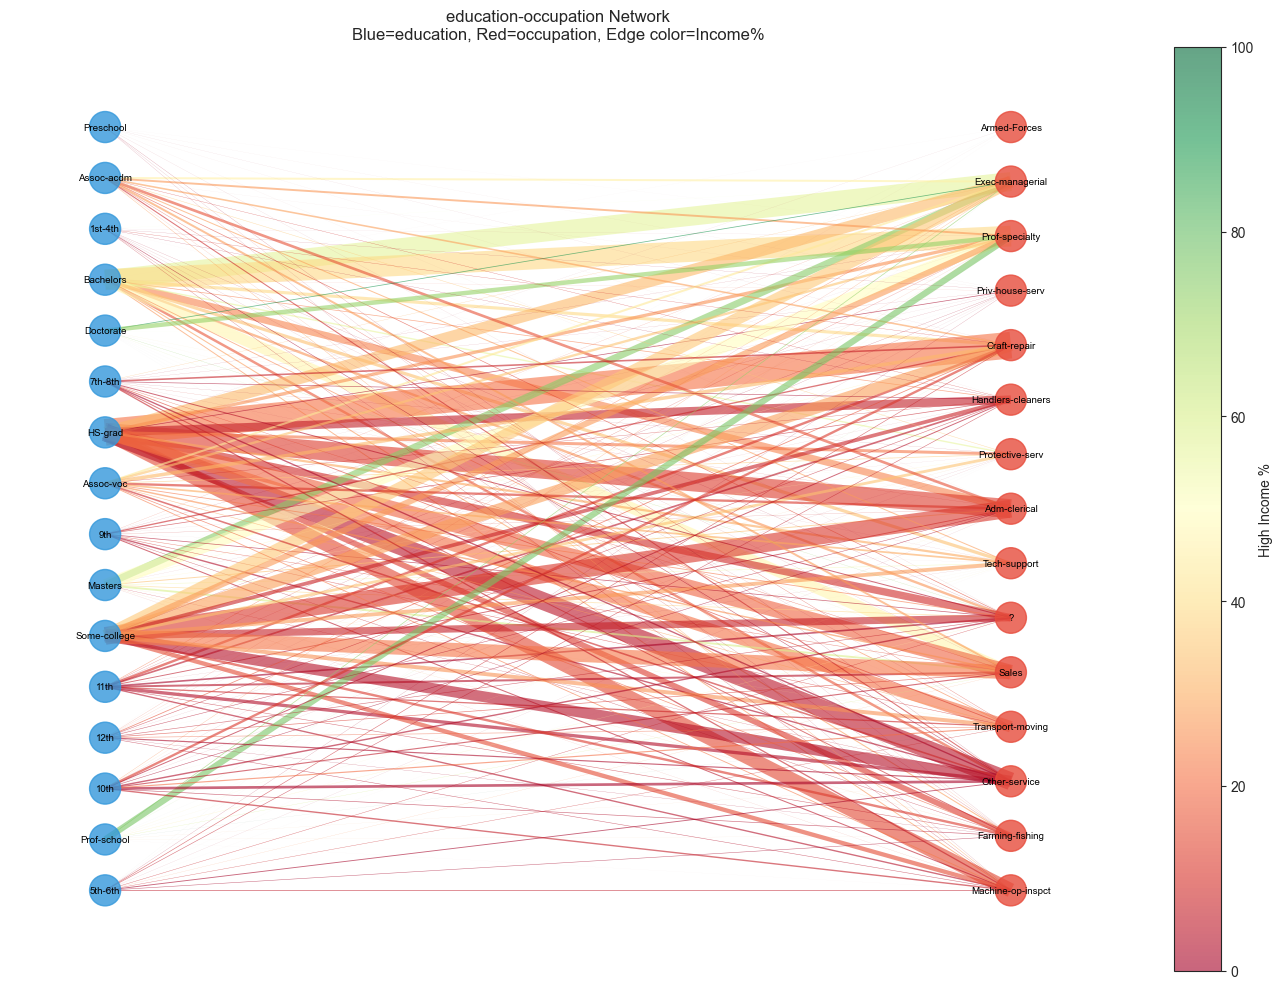

In [110]:
import networkx as nx
from networkx.algorithms import community

class graph_income_analysis:
    '''Graph Network Connectivity algorithm for target of income'''

    def __init__(self, df=None, nodes=['education', 'occupation']):
        self.df_clean = df.dropna(subset=nodes + ['income'])
        self.G = nx.Graph()
        self.nodes = nodes
        self.node_sets = {}

    def build_graph(self):
        # Add nodes by type
        for node_col in self.nodes:
            unique_vals = self.df_clean[node_col].unique()
            self.node_sets[node_col] = unique_vals
            for val in unique_vals:
                self.G.add_node(val, node_type=node_col)
        
        # Add edges by count and income percentage
        for keys, group in self.df_clean.groupby(self.nodes):
            count = len(group)
            over_50k_count = (group['income'] == '>50K').sum()
            self.G.add_edge(keys[0], keys[1], weight=count, income_pct=over_50k_count / count * 100, income_count=over_50k_count)

        return self.G
    
    def get_node_degrees(self):
        degrees = {}
        for node_col in self.nodes:
            degrees[node_col] = {node: self.G.degree(node) for node in self.node_sets[node_col]}
        return degrees
    
    def get_top_edges_by_income(self, min_weight=50, top_n=10):
        edges = [(u, v, d['income_pct'], d['weight']) 
                 for u, v, d in self.G.edges(data=True) if d['weight'] >= min_weight]
        edges.sort(key=lambda x: x[2], reverse=True)
        return edges[:top_n]
    
    def get_weighted_centrality(self):
        return {node: sum(d['weight'] for _, _, d in self.G.edges(node, data=True)) 
                for node in self.G.nodes()}
    
    def find_high_income_paths(self, from_node, top_n=5):
        '''Find which occupations from a given education lead to highest income'''
        if from_node not in self.G:
            print(f"Node '{from_node}' not found in graph")
            return []
        
        # Get all neighbors (occupations connected to this education)
        neighbors = list(self.G.neighbors(from_node))
        
        # Get income percentage for each edge
        paths = []
        for neighbor in neighbors:
            edge_data = self.G[from_node][neighbor]
            paths.append((neighbor, edge_data['income_pct'], edge_data['weight']))
        
        # Sort by income percentage descending
        paths.sort(key=lambda x: x[1], reverse=True)
        
        print(f"\n--- High income paths from '{from_node}' ---")
        for occ, pct, count in paths[:top_n]:
            print(f"  -> {occ}: {pct:.1f}% earn >50K (n={count})")
        
        return paths[:top_n]
    
    def detect_communities(self):
        '''Cluster education-occupation pairs using Louvain community detection'''
        # Use Louvain method for community detection
        communities_generator = community.louvain_communities(self.G, weight='weight', seed=42)
        self.communities = list(communities_generator)
        
        print(f"\n--- Community Detection (Louvain) ---")
        print(f"Found {len(self.communities)} communities")
        
        for i, comm in enumerate(self.communities):
            # Calculate average income % for this community
            total_income_pct = 0
            total_weight = 0
            for node in comm:
                for neighbor in self.G.neighbors(node):
                    if neighbor in comm:
                        edge = self.G[node][neighbor]
                        total_income_pct += edge['income_pct'] * edge['weight']
                        total_weight += edge['weight']
            
            avg_income = total_income_pct / total_weight if total_weight > 0 else 0
            
            # Separate by node type
            edu_nodes = [n for n in comm if self.G.nodes[n]['node_type'] == self.nodes[0]]
            occ_nodes = [n for n in comm if self.G.nodes[n]['node_type'] == self.nodes[1]]
            
            print(f"\nCommunity {i+1} (avg income: {avg_income:.1f}%):")
            print(f"  Education: {edu_nodes}")
            print(f"  Occupation: {occ_nodes}")
        
        return self.communities
    
    def print_summary(self):
        print(f"Graph has {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges")
        for node_col in self.nodes:
            print(f"  {node_col}: {len(self.node_sets[node_col])} unique values")
        
        # Degree analysis
        degrees = self.get_node_degrees()
        for node_col, deg_dict in degrees.items():
            print(f"\n--- {node_col} by connectivity ---")
            for node, deg in sorted(deg_dict.items(), key=lambda x: x[1], reverse=True)[:5]:
                print(f"  {node}: connects to {deg} nodes")
        
        # Top edges by income
        print(f"\n--- Top Education-Occupation pairs by high income % (n>=50) ---")
        for n1, n2, pct, count in self.get_top_edges_by_income(min_weight=50, top_n=10):
            print(f"  {n1} -> {n2}: {pct:.1f}% earn >50K (n={count})")
    
    def visualize(self, figsize=(14, 10), save_path=None):
        plt.figure(figsize=figsize)
        pos = nx.bipartite_layout(self.G, self.node_sets[self.nodes[0]])
        
        node_colors = ['#3498db' if self.G.nodes[n]['node_type'] == self.nodes[0] else '#e74c3c' 
                       for n in self.G.nodes()]
        
        edge_weights = [self.G[u][v]['weight'] / 100 for u, v in self.G.edges()]
        edge_colors = [self.G[u][v]['income_pct'] for u, v in self.G.edges()]
        
        nx.draw_networkx_nodes(self.G, pos, node_color=node_colors, node_size=500, alpha=0.8)
        nx.draw_networkx_labels(self.G, pos, font_size=7)
        edges = nx.draw_networkx_edges(self.G, pos, width=edge_weights, edge_color=edge_colors,
                                        edge_cmap=plt.cm.RdYlGn, alpha=0.6)
        
        plt.colorbar(edges, label='High Income %')
        plt.title(f'{self.nodes[0]}-{self.nodes[1]} Network\nBlue={self.nodes[0]}, Red={self.nodes[1]}, Edge color=Income%')
        plt.axis('off')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()
    
    def pipeline(self):
        self.build_graph()
        self.print_summary()
        self.find_high_income_paths('HS-grad')
        self.detect_communities()
        self.visualize(save_path='education_occupation_network.png')
        return self.G

# Usage
graph = graph_income_analysis(df=df, nodes=['education', 'occupation'])
graph.pipeline()

--- PCA Results ---
Explained variance ratio: [0.25934221 0.20604498]
Total variance explained: 46.54%

--- K-Means Clustering (k=4) ---
Cluster sizes: [15271 15647  1484   159]

--- Cluster Analysis ---

Cluster 0 (n=15271, 7.8% >50K):
  Avg age: 28.2
  Avg education: 9.3
  Avg hours/week: 36.5
  Avg capital gain: $205
  Top occupations: Other-service, Adm-clerical, Craft-repair

Cluster 1 (n=15647, 36.5% >50K):
  Avg age: 48.4
  Avg education: 10.7
  Avg hours/week: 43.9
  Avg capital gain: $1026
  Top occupations: Exec-managerial, Prof-specialty, Craft-repair

Cluster 2 (n=1484, 52.0% >50K):
  Avg age: 41.6
  Avg education: 11.0
  Avg hours/week: 43.4
  Avg capital gain: $0
  Top occupations: Exec-managerial, Prof-specialty, Craft-repair

Cluster 3 (n=159, 100.0% >50K):
  Avg age: 46.4
  Avg education: 12.9
  Avg hours/week: 49.8
  Avg capital gain: $99999
  Top occupations: Prof-specialty, Exec-managerial, Sales


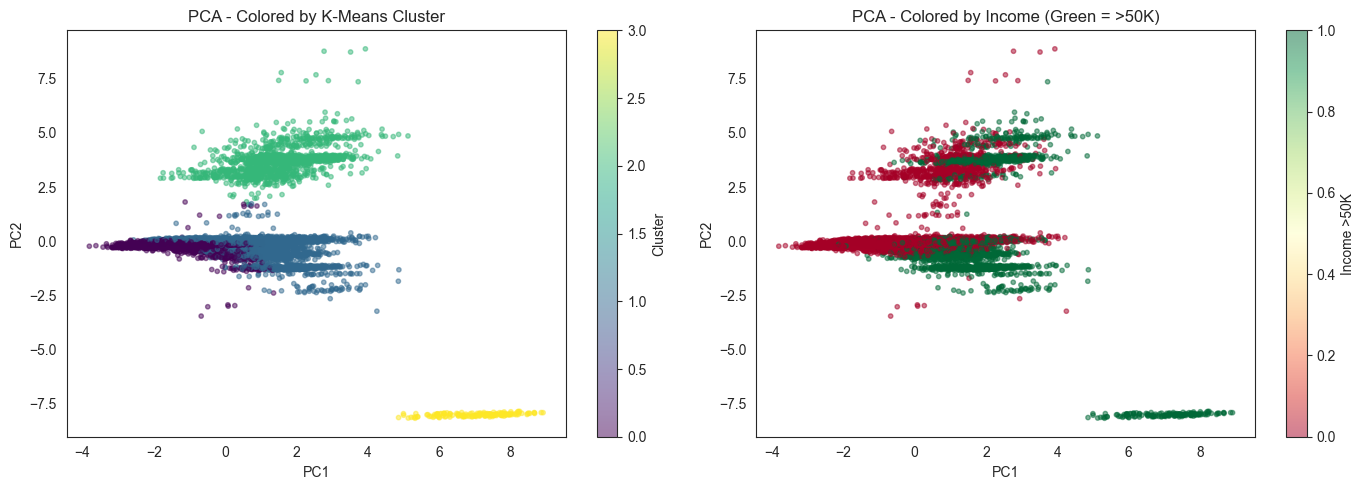

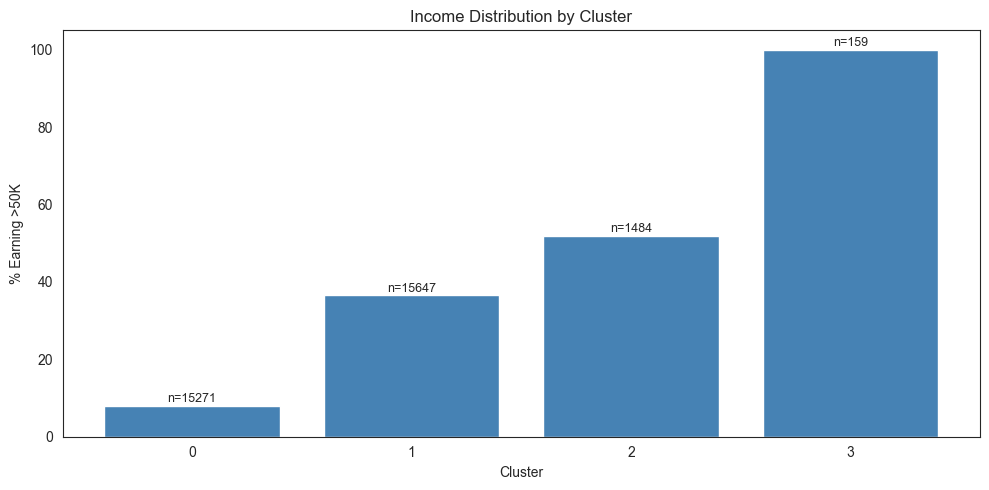

[{'cluster': 0,
  'size': 15271,
  'high_income_pct': np.float64(7.844934843821623),
  'avg_age': np.float64(28.187021151201623),
  'avg_education_num': np.float64(9.308427738851417),
  'avg_hours_per_week': np.float64(36.46277257546984),
  'avg_capital_gain': np.float64(204.89522624582543)},
 {'cluster': 1,
  'size': 15647,
  'high_income_pct': np.float64(36.511791397712024),
  'avg_age': np.float64(48.3579599923308),
  'avg_education_num': np.float64(10.719435035470058),
  'avg_hours_per_week': np.float64(43.944590017255706),
  'avg_capital_gain': np.float64(1026.4285805585735)},
 {'cluster': 2,
  'size': 1484,
  'high_income_pct': np.float64(51.95417789757413),
  'avg_age': np.float64(41.63409703504043),
  'avg_education_num': np.float64(10.988544474393532),
  'avg_hours_per_week': np.float64(43.357142857142854),
  'avg_capital_gain': np.float64(0.0)},
 {'cluster': 3,
  'size': 159,
  'high_income_pct': np.float64(100.0),
  'avg_age': np.float64(46.35849056603774),
  'avg_education_

In [111]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

class unsupervised_income_analysis:
    '''PCA + K-Means clustering to find demographic patterns correlated with income'''
    
    def __init__(self, df, n_clusters=4):
        self.df = df.dropna()
        self.n_clusters = n_clusters
        self.numeric_features = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
        self.X_scaled = None
        self.pca = None
        self.X_pca = None
        self.kmeans = None
        self.cluster_labels = None
        
    def preprocess(self):
        X = self.df[self.numeric_features].values
        self.scaler = StandardScaler()
        self.X_scaled = self.scaler.fit_transform(X)
        return self.X_scaled
    
    def apply_pca(self, n_components=2):
        self.pca = PCA(n_components=n_components)
        self.X_pca = self.pca.fit_transform(self.X_scaled)
        
        print("--- PCA Results ---")
        print(f"Explained variance ratio: {self.pca.explained_variance_ratio_}")
        print(f"Total variance explained: {sum(self.pca.explained_variance_ratio_):.2%}")
        
        return self.X_pca
    
    def apply_kmeans(self):
        '''Cluster data using K-Means'''
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)
        self.cluster_labels = self.kmeans.fit_predict(self.X_scaled)
        self.df['cluster'] = self.cluster_labels
        
        print(f"\n--- K-Means Clustering (k={self.n_clusters}) ---")
        print(f"Cluster sizes: {np.bincount(self.cluster_labels)}")
        
        return self.cluster_labels
    
    def analyze_clusters(self):
        '''Analyze income distribution and demographics per cluster'''
        print("\n--- Cluster Analysis ---")
        
        self.cluster_stats = []
        for cluster_id in range(self.n_clusters):
            cluster_data = self.df[self.df['cluster'] == cluster_id]
            n = len(cluster_data)
            high_income_pct = (cluster_data['income'] == '>50K').sum() / n * 100
            
            stats = {
                'cluster': cluster_id,
                'size': n,
                'high_income_pct': high_income_pct,
                'avg_age': cluster_data['age'].mean(),
                'avg_education_num': cluster_data['education_num'].mean(),
                'avg_hours_per_week': cluster_data['hours_per_week'].mean(),
                'avg_capital_gain': cluster_data['capital_gain'].mean()
            }
            self.cluster_stats.append(stats)
            
            print(f"\nCluster {cluster_id} (n={n}, {high_income_pct:.1f}% >50K):")
            print(f"  Avg age: {stats['avg_age']:.1f}")
            print(f"  Avg education: {stats['avg_education_num']:.1f}")
            print(f"  Avg hours/week: {stats['avg_hours_per_week']:.1f}")
            print(f"  Avg capital gain: ${stats['avg_capital_gain']:.0f}")
            
            # Top occupations in cluster
            top_occs = cluster_data['occupation'].value_counts().head(3)
            print(f"  Top occupations: {', '.join(top_occs.index.tolist())}")
        
        return self.cluster_stats
    
    def visualize_pca(self, save_path=None):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot 1: Colored by cluster
        scatter1 = axes[0].scatter(self.X_pca[:, 0], self.X_pca[:, 1], 
                                   c=self.cluster_labels, cmap='viridis', alpha=0.5, s=10)
        axes[0].set_xlabel('PC1')
        axes[0].set_ylabel('PC2')
        axes[0].set_title('PCA - Colored by K-Means Cluster')
        plt.colorbar(scatter1, ax=axes[0], label='Cluster')
        
        # Plot 2: Colored by income
        income_binary = (self.df['income'] == '>50K').astype(int).values
        scatter2 = axes[1].scatter(self.X_pca[:, 0], self.X_pca[:, 1], 
                                   c=income_binary, cmap='RdYlGn', alpha=0.5, s=10)
        axes[1].set_xlabel('PC1')
        axes[1].set_ylabel('PC2')
        axes[1].set_title('PCA - Colored by Income (Green = >50K)')
        plt.colorbar(scatter2, ax=axes[1], label='Income >50K')
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()
    
    def visualize_cluster_income(self, save_path=None):
        cluster_ids = [s['cluster'] for s in self.cluster_stats]
        income_pcts = [s['high_income_pct'] for s in self.cluster_stats]
        sizes = [s['size'] for s in self.cluster_stats]
        
        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(cluster_ids, income_pcts, color='steelblue')
        
        # Add size labels on bars
        for bar, size in zip(bars, sizes):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'n={size}', ha='center', fontsize=9)
        
        ax.set_xlabel('Cluster')
        ax.set_ylabel('% Earning >50K')
        ax.set_title('Income Distribution by Cluster')
        ax.set_xticks(cluster_ids)
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
        plt.show()
    
    def pipeline(self):
        self.preprocess()
        self.apply_pca()
        self.apply_kmeans()
        self.analyze_clusters()
        self.visualize_pca(save_path='pca_clusters.png')
        self.visualize_cluster_income(save_path='cluster_income.png')
        return self.cluster_stats

# Usage
unsupervised = unsupervised_income_analysis(df, n_clusters=4)
unsupervised.pipeline()

### Graph Algorithm Summary

**Problem Statement:** What is the relationship structure between occupations and education levels, and which career pathways are most associated with high income?

**Key Findings:**

The problem statement was to find pahtways to "high income" (defined in the data set as >50K). There were 2 communities found for that in the graph algorithm analysis.. The clearest path to >50K income is through **advanced education (Bachelors+)** combined with **professional/managerial occupations**. This pathway of college-educationed to leadership roles makes sense for higher income bins. The next path way is less common, but 10.6% of hs-educated have a path way to leadership roles that also result in the >50K income bin.

**Why Graph Analysis Worked Well for this:**
- Reveals structural relationships between categorical variables that aren't visible in simple cross-tabulations
- Community detection identifies natural groupings across each node-type without predefined labels (finding results for high income lables across different education levels was key)
- Edge weights capture both frequency (how common a path is) and outcome (income percentage)

### Unsupervised Learning Algorithm Summary

**Problem Statement:** Are there natural demographic clusters within the population, and do these clusters correlate with income levels?

**Methodology:**
1. **PCA (Principal Component Analysis)** - Reduced 5 numeric features (age, education_num, capital_gain, capital_loss, hours_per_week) to 2 components for visualization. The first 2 components explain ~46.5% of variance.
2. **K-Means Clustering (k=4)** - Grouped individuals into 4 clusters based on scaled numeric features.

**Key Findings:**

-  **Demographic profiles identified:**
   - **"Young Entry-Level"** (Cluster 0): Low income, just starting careers
   - **"Experienced Workers"** (Cluster 1): Middle-aged, moderate success through tenure
   - **"Professionals"** (Cluster 2): Career-focused, salary-based high earners
   - **"Investors"** (Cluster 3): Small group with massive capital gains

**Why Unsupervised Learning Worked Well For This:**
- Discovers natural groupings without using income as an input (then validates against income)
- PCA reduces dimensionality for visualization while preserving variance
- K-Means finds clusters based on similarity in feature space, revealing patterns not obvious from individual features

## **Evaluation & Comparison (5 points)**

The Graph Network analysis revealed structural relationships between education and occupation. This let us answer higher dimensional questions about which education-occupation *combinations* lead to high income. The graph data structure fit nicelt with the community detection, showing us which career pathways clump together under income levels. The Unsupervised Learning analysis showed individual-level demographic patterns. Using PCA we could combine age, education, hours, and capital gain as features that as an overall summary could correlate with income. Clustering on the PCA axes show us different profiles of people earning different profiles of income. We saw Young Entry-Level demographics, Experience Worker demographics, Professionals, and Investors clearly identifyiable in the actual data.

Comparing the two modeling techniques, the graph algorithm let us analyze not the raw data points, but relationships (educational-occupation pairs), where the PCA kept each data point as an individual person. The Graph was also better at categorical features where the Unsupervised Learning was better at numerical data. The Graph algorithm worked on easy to interpret paths, where in PCA it is hard to determine what each axis represents literally, but clustering can help that interperation step. But the Graph algorithm is weaker in analyzing indivitual variation, as node types are categorical. 

# **Q3: Gaussian Mixture Models and Expectation-Maximization**

**Analyzing runtime and implementing GMMs for a single-variate dataset:** Unlike traditional clustering, GMMs use **probabilistic modeling** to represent data as a **mixture of Gaussians**, making them useful for capturing **uncertainty** and **overlapping distributions**.

---

## Understanding Gaussian Mixture Models and the EM Algorithm (5 points)

The **Expectation-Maximization (EM) algorithm** is used to iteratively find a probablistic model's ideal parameters, optimized by the maximum likelihood estimates. The Gaussian Probability Density Function (GPDF) is a model that computes how likely each point of data comes from a certain Gaussian component/subset of the whole dataset. But the shape (the parameters) of each Gaussian component is completely unknown. We do know that combined (or mixed), they should fit over the dataset itself though. So each component is parameterized on its mean (`mu`), its standard deviation (`sigma`), and the mixing probability (`p_mix`, the normalized weight that this subset has in the overall population). The EM algorithm alternates between two steps. The **E-step (Expectation)** computes the probability that each data point belongs to each Gaussian component, given the current parameter estimates. These are called "membership probabilities" or "responsibilities." The **M-step (Maximization)** then updates the parameters (`mu`, `sigma`, `p_mix`) to maximize the expected log-likelihood, using the membership probabilities as weights. Each iteration is guaranteed to increase (or maintain) the log-likelihood, and the algorithm repeats until the log-likelihood stabilizes (converges).

Real-world data often comes from multiple underlying subpopulations. In the Iris dataset, petal length varies by species — Setosa has short petals, Virginica has long petals, and Versicolor is in between. A single Gaussian would poorly fit this multimodal distribution. A *mixture* of Gaussians can capture each subpopulation's distribution separately, then combine them. This is more flexible than assuming all data comes from one bell curve, and it naturally handles overlapping distributions where boundaries between groups are fuzzy.

**Soft assignments vs. hard assignments:**
Unlike K-Means, which assigns each point to exactly one cluster (hard assignment), GMMs assign each point a *probability* of belonging to each cluster (soft assignment). A data point might have 70% probability of being Versicolor and 30% Virginica — reflecting genuine uncertainty when species overlap in petal length. This probabilistic approach better captures the reality that cluster boundaries aren't always sharp, and it provides richer information about each point's relationship to the underlying distributions. Even though the M-step is thought of as "treating imputed data as real data", using probabilities adjust for the fact that this is not actually real data.

## Implementation & Visualization (15 & 5 points)

Initial mu: [4.7 1.7 6.9]
Initial sigma: [1.31830779 1.60173142 2.20902178]
Initial p_mix: [0.3809182  0.11744639 0.50163541]
Converged after 271 iterations

=== GMM Results ===
Iterations: 271
Final log-likelihood: -199.8183

Final parameters:
  Cluster 0: mu=4.5066, sigma=0.6178, p_mix=0.4321
  Cluster 1: mu=1.4620, sigma=0.1719, p_mix=0.3333
  Cluster 2: mu=5.6412, sigma=0.6172, p_mix=0.2346


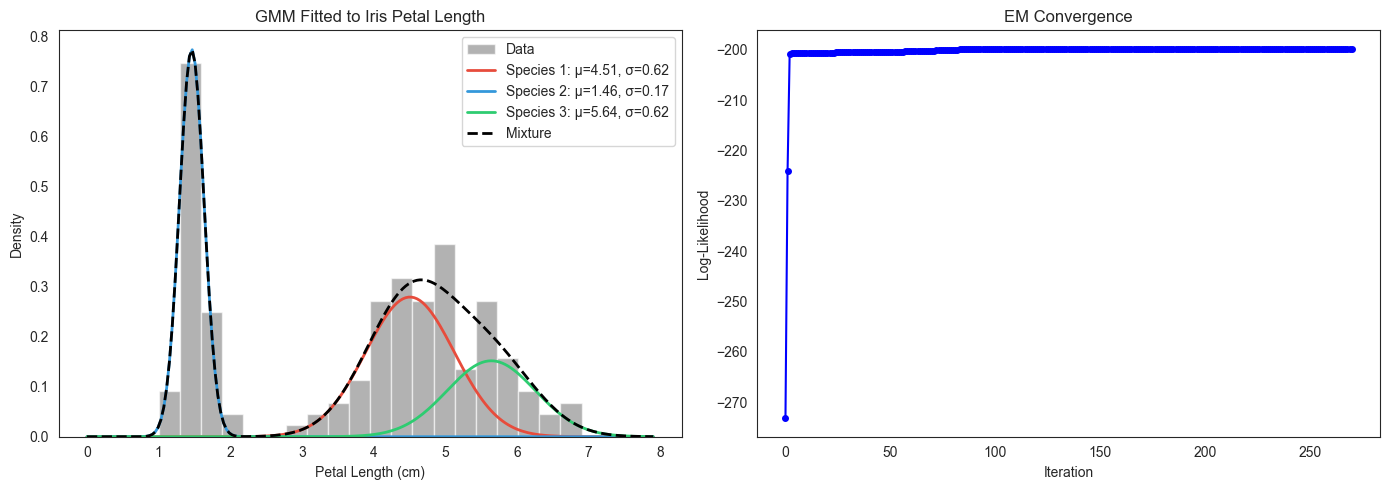

In [112]:
## Import the dataset ##

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

class gaussian_mixture_model:
    
    def __init__(self, df, feature_col='petal length (cm)', max_iters=1000, convergence_thresh=1e-4):
        self.X = df[feature_col].values
        self.n = len(self.X)
        self.k = df['species'].nunique()
        self.max_iters = max_iters
        self.convergence_thresh = convergence_thresh
        self.log_likelihoods = []

    def gaussian_pdf(self, x, mu, sigma):
        '''Gaussian PDF for a single point'''
        coeff = 1 / (((2 * np.pi) ** 0.5) * sigma)
        exponent = -0.5 * ((x - mu) / sigma) ** 2
        return coeff * np.exp(exponent)

    def initialize_em(self):
        '''Random initialization of parameters'''
        np.random.seed(42)
        self.mu = self.X[np.random.choice(self.n, self.k, replace=False)]
        data_std = np.std(self.X)
        self.sigma = np.random.uniform(0.5 * data_std, 1.5 * data_std, size=self.k)
        self.p_mix = np.random.dirichlet(np.ones(self.k)) # k values that add to 1
        
        print(f"Initial mu: {self.mu}")
        print(f"Initial sigma: {self.sigma}")
        print(f"Initial p_mix: {self.p_mix}")

    def e_step(self):
        '''E-Step: Calculate membership probabilities (source: Module 5 Activity)'''
        # Calculate numerators: P(x_i | z=k) * P(z=k) for each (i, k) pair
        numerators = []
        for j in range(self.k):
            for i in range(self.n):
                value = self.gaussian_pdf(self.X[i], self.mu[j], self.sigma[j]) * self.p_mix[j]
                numerators.append(value)
        
        # Compute denominators: sum across components for each data point
        denominators = []
        for i in range(self.n):
            denom = sum(numerators[j * self.n + i] for j in range(self.k))
            denominators.append(denom)
        
        # Calculate membership probabilities
        self.p_members = []
        for j in range(self.k):
            for i in range(self.n):
                idx = j * self.n + i
                self.p_members.append(numerators[idx] / denominators[i])
        
        # Compute p_k_n (sum of membership probabilities for each cluster)
        self.p_k_n = []
        for j in range(self.k):
            start = j * self.n
            end = start + self.n
            self.p_k_n.append(sum(self.p_members[start:end]))

    def m_step(self):
        '''M-Step: Update means, std devs, and mixing probabilities (source: Module 5 Activity)'''
        new_mu = []
        new_sigma = []
        
        for j in range(self.k):
            # Get membership probabilities for this cluster
            start = j * self.n
            probs_k = self.p_members[start:start + self.n]
            
            # Update mean: sum(prob * x) / sum(prob)
            weighted_sum = 0
            for i in range(self.n):
                weighted_sum += probs_k[i] * self.X[i]
            mu_k = weighted_sum / self.p_k_n[j]
            new_mu.append(mu_k)
            
            # Update std dev: sqrt(sum(prob * (x - mu)^2) / sum(prob))
            weighted_sq_sum = 0
            for i in range(self.n):
                weighted_sq_sum += probs_k[i] * ((self.X[i] - mu_k) ** 2)
            sigma_k = (weighted_sq_sum / self.p_k_n[j]) ** 0.5
            new_sigma.append(sigma_k)
        
        # Update mixing probabilities: p_k_n / n
        new_pi = []
        for j in range(self.k):
            new_pi.append(self.p_k_n[j] / self.n)
        
        self.mu = np.array(new_mu)
        self.sigma = np.array(new_sigma)
        self.p_mix = np.array(new_pi)

    def compute_log_likelihood(self):
        '''Compute log-likelihood of the data given current parameters  (source: Module 5 Activity)'''
        log_likelihood = 0
        for i in range(self.n):
            likelihood_i = 0
            for j in range(self.k):
                likelihood_i += self.p_mix[j] * self.gaussian_pdf(self.X[i], self.mu[j], self.sigma[j])
            log_likelihood += np.log(likelihood_i)
        return log_likelihood

    def check_convergence_with_log_likelihood(self):
        '''Check if log-likelihood has stabilized (difference between iterations < threshold)'''
        # Compute log-likelihood after M-step
        log_likelihood = self.compute_log_likelihood()
        self.log_likelihoods.append(log_likelihood)

        if len(self.log_likelihoods) < 2:
            return False
        diff = abs(self.log_likelihoods[-1] - self.log_likelihoods[-2])
        return diff < self.convergence_thresh

    def print_report(self):
        '''Print final parameters'''
        print("\n=== GMM Results ===")
        print(f"Iterations: {self.iterations}")
        print(f"Final log-likelihood: {self.log_likelihoods[-1]:.4f}")
        print(f"\nFinal parameters:")
        for k in range(self.k):
            print(f"  Cluster {k}: mu={self.mu[k]:.4f}, sigma={self.sigma[k]:.4f}, p_mix={self.p_mix[k]:.4f}")

    def visualize(self):
        '''Plot histogram with fitted Gaussians overlaid'''
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot 1: Histogram with Gaussians
        ax1 = axes[0]
        x_range = np.linspace(self.X.min() - 1, self.X.max() + 1, 200)
        
        # Histogram
        ax1.hist(self.X, bins=20, density=True, alpha=0.6, color='gray', label='Data')
        
        # Individual Gaussians
        colors = ['#e74c3c', '#3498db', '#2ecc71']
        for k in range(self.k):
            y = self.p_mix[k] * self.gaussian_pdf(x_range, self.mu[k], self.sigma[k])
            ax1.plot(x_range, y, color=colors[k], linewidth=2, 
                     label=f'Species {k+1}: μ={self.mu[k]:.2f}, σ={self.sigma[k]:.2f}')
        
        # Mixture (sum of all Gaussians)
        mixture = np.zeros_like(x_range)
        for k in range(self.k):
            mixture += self.p_mix[k] * self.gaussian_pdf(x_range, self.mu[k], self.sigma[k])
        ax1.plot(x_range, mixture, 'k--', linewidth=2, label='Mixture')
        
        ax1.set_xlabel('Petal Length (cm)')
        ax1.set_ylabel('Density')
        ax1.set_title('GMM Fitted to Iris Petal Length')
        ax1.legend()
        
        # Plot 2: Log-likelihood convergence
        ax2 = axes[1]
        ax2.plot(self.log_likelihoods, 'b-o', markersize=4)
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('Log-Likelihood')
        ax2.set_title('EM Convergence')
        
        plt.tight_layout()
        plt.savefig('gmm_visualization.png', dpi=150)
        plt.show()

    def pipeline(self):
        self.initialize_em()
        for iteration in range(self.max_iters):
            self.e_step()
            self.m_step()            
            if self.check_convergence_with_log_likelihood():
                print(f"Converged after {iteration + 1} iterations")
                break
        else:
            print(f"Reached max iterations ({self.max_iters})")
        
        self.iterations = iteration + 1
        self.print_report()
        self.visualize()

gmm = gaussian_mixture_model(df)
gmm.pipeline()

## Runtime Complexity Analysis (5 points)

Let **n** = number of data points, **k** = number of Gaussian components, **T** = number of iterations until convergence. Starting with the sub-steps:
- `initialize_em()` is `O(k)` as it generates k random values for each parameter. 
- `e_step()` is `O(n x k)` as it generates membership probablites for each `n` data point going into each cluster `k`. Each loop in the `e_step()` is calculating the components of a fraction and so in total, they are `O(n x k)` 
- `m_step()` is `O(n x k)` as it has to sum over all data points with the newly calculated parameters to update the model parameters `mu` and `sigma`. 
- ` check_convergence_with_log_likelihood()` recalculates `O(n x k)` log_likelihoods.

Each of these sub-steps is `O(n x k)` or better, and they loop `T_max` times. Therefore, the overall runtime complexity is `O(T x n x k)`.
| Notation | Complexity | Explanation |
|----------|------------|-------------|
| **Big O** | **O(T × n × k)** | Upper bound: worst case where T = max_iters |
| **Big Θ** | **Θ(T × n × k)** | Tight bound: every iteration does exactly O(n × k) work |
| **Big Ω** | **Ω(n × k)** | Lower bound: at minimum, one full iteration must complete |

The runtime can be effected heavily by the inital parameters as well. If they are chosen close to the optimal distributions, then `T` tends towards 1. It helps to bound it as well.